In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

import optuna

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("health_insurance_risk_dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

  policy_id  age  gender   bmi smoker region  annual_income occupation  \
0   P100000   59    Male  33.3     No   West        1080761   Salaried   
1   P100001   49  Female  26.1    Yes   West         865752   Salaried   
2   P100002   35    Male  20.9     No   East         787147   Salaried   
3   P100003   63  Female  27.5     No  North        1081382   Salaried   
4   P100004   28    Male  26.5     No   East         955093   Salaried   

  marital_status  number_of_dependents  exercise_frequency chronic_disease  \
0         Single                     3                   4              No   
1         Single                     4                   6             Yes   
2         Single                     0                   6              No   
3        Married                     2                   4              No   
4         Single                     4                   6              No   

   past_claims_count  credit_score  policy_tenure_years  coverage_amount  \
0         

In [8]:
# Encode categorical columns automatically
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [10]:
target_column = "claim_amount"   # CHANGE if needed

X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mse = mean_squared_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 16788234303.288
R2 Score: 0.3281064719096468


In [12]:
param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_dt = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y

Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: nan


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
def build_model(neurons=64, dropout_rate=0.3, learning_rate=0.001):
    model = keras.Sequential([
        layers.Dense(neurons, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(dropout_rate),
        
        layers.Dense(neurons//2, activation='relu'),
        layers.Dropout(dropout_rate),
        
        layers.Dense(1)   
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model


In [25]:
model = build_model()

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 40503574528.0000 - mae: 124633.3984 - val_loss: 39138508800.0000 - val_mae: 121877.7500
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40387690496.0000 - mae: 124482.4531 - val_loss: 38889254912.0000 - val_mae: 121550.2578
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 39905710080.0000 - mae: 123832.5469 - val_loss: 38163959808.0000 - val_mae: 120570.8281
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 38844973056.0000 - mae: 122377.1719 - val_loss: 36806832128.0000 - val_mae: 118694.5000
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37125935104.0000 - mae: 119969.5938 - val_loss: 34778902528.0000 - val_mae: 115784.2812
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 34833399808.0000 - mae: 116615.0000 - val_loss: 32202135552.0000 - val_mae: 111883.6719
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 31815417856.0000 - mae: 111942.3672 - val_loss: 29075806208.000

In [26]:
y_pred_ann = (model.predict(X_test_scaled) > 0.5).astype(int)

print("ANN Classification Report")
print(classification_report(y_test, y_pred_ann))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     829.0
           1       0.00      0.00      0.00       0.0
         165       0.00      0.00      0.00       1.0
         720       0.00      0.00      0.00       1.0
        1342       0.00      0.00      0.00       1.0
        4118       0.00      0.00      0.00       1.0
        4121       0.00      0.00      0.00       1.0
        6397       0.00      0.00      0.00       1.0
        7089       0.00      0.00      0.00       1.0
        7122       0.00      0.00      0.00       1.0
        7672       0.00      0.00      0.00       1.0
        8890       0.00      0.00      0.00       1.0
        9340       0.00      0.00      0.00       1.0
       10102       0.00      0.00      0.00       1.0
       10301       0.00      0.00      0.00       1.0
       10472       0.00      0.00      0.00       1.0
       11420    

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [28]:
def objective(trial):

    neurons = trial.suggest_int("neurons", 32, 256)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    model = build_model(neurons, dropout_rate, learning_rate)

    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    # For regression → minimize validation loss (MSE)
    return min(history.history['val_loss'])
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Best Trial:", study.best_trial.params)

[I 2026-03-03 15:13:50,116] A new study created in memory with name: no-name-87fc2d6c-bb7e-4d2d-808e-7eb67301acb6
[I 2026-03-03 15:14:03,454] Trial 0 finished with value: 8071057408.0 and parameters: {'neurons': 45, 'dropout_rate': 0.2402197901328587, 'learning_rate': 0.008815280084996643, 'batch_size': 64}. Best is trial 0 with value: 8071057408.0.
[I 2026-03-03 15:14:34,973] Trial 1 finished with value: 8522802176.0 and parameters: {'neurons': 90, 'dropout_rate': 0.21094100820156117, 'learning_rate': 0.0003127607244087892, 'batch_size': 16}. Best is trial 0 with value: 8071057408.0.
[I 2026-03-03 15:14:47,994] Trial 2 finished with value: 8058959872.0 and parameters: {'neurons': 161, 'dropout_rate': 0.4962168703170253, 'learning_rate': 0.008336207588021538, 'batch_size': 64}. Best is trial 2 with value: 8058959872.0.
[I 2026-03-03 15:15:24,565] Trial 3 finished with value: 8070882304.0 and parameters: {'neurons': 230, 'dropout_rate': 0.36901218029437055, 'learning_rate': 0.0062189133

Best Trial: {'neurons': 195, 'dropout_rate': 0.4340754142632675, 'learning_rate': 0.007153858748180152, 'batch_size': 16}


In [29]:
print("Unique classes:", y.nunique())
print(y.value_counts())

Unique classes: 5799
claim_amount
0         4152
500000       3
186528       2
300000       2
86517        2
          ... 
29704        1
155789       1
277761       1
103527       1
544732       1
Name: count, Length: 5799, dtype: int64


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step
Model Evaluation:
MSE : 7808640512.0
RMSE: 88366.5123901583
MAE : 50390.51953125
R2  : 0.6874849796295166


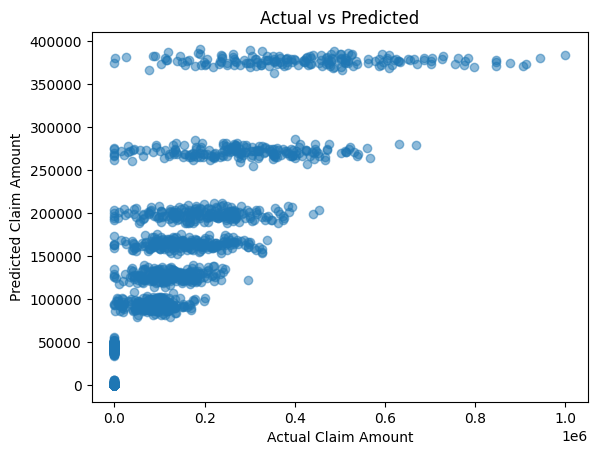

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Predict
y_pred = model.predict(X_test_scaled).ravel()

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Claim Amount")
plt.ylabel("Predicted Claim Amount")
plt.title("Actual vs Predicted")
plt.show()